# ***RQ2: Can dynamic graph based deep learning models detect money laundering activities earlier than static classification baselines?***
---
---

### **Loading & Cleaning Process - Transactions - Graph:**
---

For this research question, I will use only the Elliptic++ dataset, focusing specifically on the transaction data. I first combined the transaction features with the class labels using the txId. During preprocessing, I removed all rows with missing values and relabeled class 2 as 0 (licit class) so that the task becomes a binary classification problem. I then applied a time-based split, using time steps 1–39 for training and 40–49 for testing, which is roughly an 80/20 split. For the rest of the workflow process I used the txs_edgelist as edges and the dataset that we created before as nodes.

### **Workflow Process:**
---

I divided the workflow into three main parts. 

First, I will build a **static feature baseline** using tree-based models such as Random Forest, XGBoost, and LightGBM, since these performed better than linear models in my first research question, I will use the simple and simple_balance setup for all models. 

Second, I will implement **static graph neural networks** using the txs_edgelist as edges and the dataset that we created as nodes, including GCN and GraphSAGE, to test whether graph structure helps improve the detection of money laundering. 

Finally, in the third part, I will implement a **dynamic graph** model, EvolveGCN, and compare its performance to see if it can detect money laundering earlier than the static approaches.

In [2]:
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Project root: c:\University\Year4\Thesis\AML-Thesis
src exists: True


## **Dataset:**

In [3]:
from src.data_loader import _load_raw_elliptic_transactions_features
from src.data_loader import _load_raw_elliptic_transactions_classes

raw_trn_features = _load_raw_elliptic_transactions_features()
raw_trn_features

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
raw_trn_classes = _load_raw_elliptic_transactions_classes()
raw_trn_classes

,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2
...,...,...
203764,158304003,3
203765,158303998,3
203766,158303966,3
203767,161526077,3


In [5]:
from src.data_loader import _load_raw_elliptic_transactions_combined

trn_combined = _load_raw_elliptic_transactions_combined()
trn_combined

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


### **Cleaning Process - Transaction Graph:**

1. Drop NaN rows
2. Rename class 2 -> 0 - The dataset uses labels 1 for illicit, 2 for licit, and 3 for unknown. For binary classification, labels should be 0 and 1. So, licit is changed to 0 and illicit stays as 1.

**The same preprocessing was used for all the three stages!**

---
---

### **Loading Process - Transactions:**
---

- Load raw transaction features
- Load raw transaction classes
- Merge features and classes on txId
- Preprocess merged dataset and save cleaned version
- Load cleaned dataset
- Split into features (X) and target (y)
- Apply time-based train/test split using Time step 1-39 for training and 40-49 testing
- Remove Target and Time step (mask) from features
- Apply simple and simple_balance setup for all the experiments
---
---

In [6]:
from src.data_loader import _load_preprocessed_elliptic_transactions_combined

trn_combined_cleaned = _load_preprocessed_elliptic_transactions_combined()
trn_combined_cleaned

,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,-0.118555,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,0
1,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,5.252974,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,0
2,1,-0.172726,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163383,-0.169201,...,0.040774,0.040774,0.040774,0.040774,9.480000e-04,0.039726,0.020337,0.020337,0.040674,0
3,1,-0.172921,-0.158783,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163581,-0.169397,...,0.010000,0.010000,0.010000,0.010000,2.900000e-03,0.006900,0.004900,0.004900,0.009800,0
4,1,-0.169967,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160559,-0.166417,...,0.478277,0.478277,0.478277,0.478277,4.630000e-02,0.431877,0.239088,0.239088,0.478177,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46040,49,-0.039416,-0.118083,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.026985,-0.034715,...,21.175927,21.175927,21.175927,21.175927,4.005752e-02,21.135512,10.587785,10.587785,21.175569,0
46041,49,-0.050308,-0.112834,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.038129,-0.045703,...,19.449182,19.449182,19.449182,19.449182,1.000000e-02,19.438805,9.724402,9.724402,19.448805,0
46042,49,-0.154605,-0.116753,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.144840,-0.150918,...,2.914019,2.914019,2.914019,2.914019,3.886639e-01,2.524993,1.456828,1.456828,2.913657,0
46043,49,0.708000,-0.118083,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,0.737731,0.719284,...,139.670987,139.670987,139.670987,139.670987,1.018483e-01,139.568782,69.835315,69.835315,139.670630,0


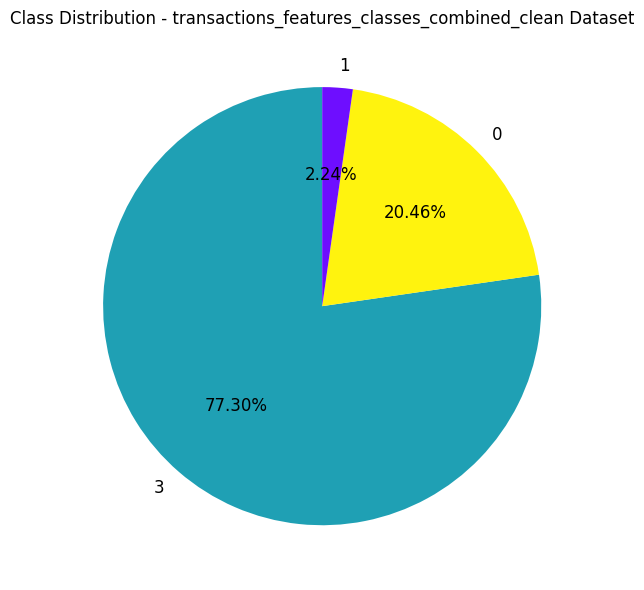

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean_datasets/elliptic_plus_plus/transactions_graph_clean.csv')

class_counts = df['class'].value_counts()
labels = class_counts.index.tolist()
sizes = class_counts.values

colors = ["#1fa0b4", "#fff30e", "#6e0eff"]  # yellow for 0, purple for 1, blue for 3

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Class Distribution - transactions_features_classes_combined_clean Dataset')
plt.tight_layout()
plt.show()

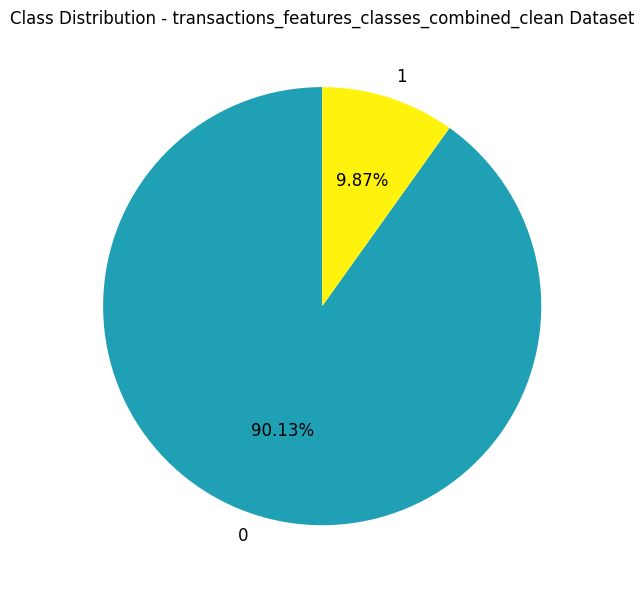

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean_datasets/elliptic_plus_plus/transactions_graph_clean.csv')
df = df[df['class'] != 3]

class_counts = df['class'].value_counts()
labels = class_counts.index.tolist()
sizes = class_counts.values

colors = ["#1fa0b4", "#fff30e"]  #  blue for 0, yellow for 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Class Distribution - transactions_features_classes_combined_clean Dataset')
plt.tight_layout()
plt.show()

Based on the distribution of the dataset excluding class 3 sice its masked in the results, it is clear that the data is highly imbalanced, with 90.13% licit and 9.87% illicit transactions. Because of this, a model that labels everything as "licit" would achieve high accuracy but would be useless for AML purposes. Therefore, accuracy will not be considered as the main metric. Instead, the focus will be on the F1-score, which balances precision and recall. Precision shows how many flagged transactions are actually illicit, while recall shows how many illicit transactions are correctly identified. In addition, ROC-AUC will be used to evaluate threshold-independent performance and allow a fair comparison of all models.

## **Static Feature Baseline:**
---

### **Random Forest:**
---

In [13]:
from IPython.display import display
from src.training import run_random_forest_graph_experiments
from src.training import run_xgboost_graph_experiments
from src.training import run_lightgbm_graph_experiments

rf_agg,   rf_per_ts   = run_random_forest_graph_experiments()
rf_agg

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-graph,Random Forest,simple,0.974986,0.973615,0.580189,0.727094,0.924149
1,elliptic-transactions-graph,Random Forest,simple_balanced,0.973361,0.974930,0.550314,0.703518,0.933417


In [14]:
print("Random Forest — simple")
display(rf_per_ts["simple"])

Random Forest — simple


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,1.000000,0.616071,0.762431,0.906898
1,41,1127,116,1.000000,0.922414,0.959641,0.986864
2,42,2142,239,0.994764,0.794979,0.883721,0.962822
3,43,1327,24,0.000000,0.000000,0.000000,0.642684
4,44,1578,24,0.166667,0.041667,0.066667,0.819297
5,45,1198,5,0.000000,0.000000,0.000000,0.781727
6,46,711,2,0.500000,0.500000,0.500000,0.955924
7,47,836,22,0.000000,0.000000,0.000000,0.835883
8,48,471,36,0.000000,0.000000,0.000000,0.894987
9,49,476,56,1.000000,0.017857,0.035088,0.925510


In [15]:
print("Random Forest — simple_balanced")
display(rf_per_ts["simple_balanced"])

Random Forest — simple_balanced


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,1.000000,0.598214,0.748603,0.907708
1,41,1127,116,1.000000,0.887931,0.940639,0.981420
2,42,2142,239,0.994382,0.740586,0.848921,0.966694
3,43,1327,24,0.000000,0.000000,0.000000,0.648903
4,44,1578,24,0.166667,0.041667,0.066667,0.834808
5,45,1198,5,0.000000,0.000000,0.000000,0.808131
6,46,711,2,1.000000,0.500000,0.666667,0.977080
7,47,836,22,0.000000,0.000000,0.000000,0.893065
8,48,471,36,0.000000,0.000000,0.000000,0.925415
9,49,476,56,1.000000,0.017857,0.035088,0.931781


#### **Results:**
---

**Aggregate results:**

The Random Forest model shows very high **precision** (around 97%), which means that when it predicts an illicit transaction, it is almost always correct. However, the **recall** is low (around 55–58%), so the model misses many illicit transactions around half. The overall **F1** score (0.70–0.73) is acceptable but not strong. Class balancing does not improve performance, the ***simple_balanced*** version has slightly reduces recall and F1, likely because the test distribution is very different from the training distribution.

---

**Per-Timestep Results:**

The aggregate numbers hide the most important finding. When we look at F1 per time step, we see two very different groups:

**Group 1 — Stable performance (steps 40–42):** The model performs very well on these time steps. The patterns of illicit behaviour are similar to the training data, so the model can still recognise them.

**Group 2 — Model collapse (steps 43–49):** Starting at time step 43, the model almost stops detecting illicit transactions. This matches the well-known **"dark market shutdown"** event in the Elliptic dataset, where a major illicit marketplace was closed. The statistical patterns of illicit activity changed in the real world, and the model trained only on pre-shutdown data and cannot adapt.

---

Interestingly, even when F1 drops to near zero, ROC-AUC remains high. This means the model can still rank illicit transactions higher than licit ones, but its prediction threshold is no longer suitable. Basically, the model still “sees” suspicious transactions but is not confident enough to classify them as illicit.

Finally, small sample sizes in some time steps (like step 46) make the results unreliable, and differences between ***simple_balanced*** and ***simple*** setups are mostly due to randomness. Overall, this confirms that the main problem is concept drift, not class imbalance, and that static models struggle when patterns change over time.

*This creates a clear baseline floor that the static GNN and the dynamic GNN will need to improve. The main research question is whether temporal modelling can keep performance stable across steps 43–49, where the static Random Forest essentially fails.*

---
---

### **XGBoost:**
---

In [30]:
xgb_agg,  xgb_per_ts  = run_xgboost_graph_experiments()
xgb_agg

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:53:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-graph,XGBoost,simple,0.975077,0.959184,0.591195,0.731518,0.947289
1,elliptic-transactions-graph,XGBoost,simple_balanced,0.974083,0.872068,0.643082,0.740271,0.953025


In [31]:
print("XGBoost — simple")
display(xgb_per_ts["simple"])

XGBoost — simple


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,0.986301,0.642857,0.778378,0.928694
1,41,1127,116,1.000000,0.939655,0.968889,0.987934
2,42,2142,239,0.969388,0.794979,0.873563,0.971677
3,43,1327,24,0.000000,0.000000,0.000000,0.793937
4,44,1578,24,0.142857,0.041667,0.064516,0.799657
5,45,1198,5,0.000000,0.000000,0.000000,0.858676
6,46,711,2,0.500000,0.500000,0.500000,0.973907
7,47,836,22,1.000000,0.045455,0.086957,0.899765
8,48,471,36,0.000000,0.000000,0.000000,0.962133
9,49,476,56,0.666667,0.035714,0.067797,0.943707


In [32]:
print("XGBoost — simple_balanced")
display(xgb_per_ts["simple_balanced"])

XGBoost — simple_balanced


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,0.950617,0.687500,0.797927,0.939431
1,41,1127,116,0.956522,0.948276,0.952381,0.990586
2,42,2142,239,0.910798,0.811715,0.858407,0.974280
3,43,1327,24,0.000000,0.000000,0.000000,0.805577
4,44,1578,24,0.181818,0.083333,0.114286,0.831993
5,45,1198,5,0.000000,0.000000,0.000000,0.885499
6,46,711,2,0.333333,0.500000,0.400000,0.968265
7,47,836,22,0.428571,0.136364,0.206897,0.903786
8,48,471,36,0.764706,0.361111,0.490566,0.966667
9,49,476,56,0.642857,0.160714,0.257143,0.953316


#### **Results:**
---
**Aggregate results:**

***XGBoost*** shows similar overall performance to ***Random Forest***, with an **F1 score around 0.73**. However, it has a higher **ROC-AUC (0.95 vs 0.93)**, which means it is better at ranking illicit transactions. Unlike Random Forest, ***class balancing improves XGBoost’s performance***: **recall increases from 0.59 to 0.64** and **F1 improves from 0.732 to 0.740**, although **precision drops slightly**. This happens because XGBoost handles class imbalance more effectively by adjusting the loss function during training.

---

**Per-timestep results:**

**Both models perform well in the stable period (steps 40–42)**, where the data is similar to training. However, **after the shutdown (steps 43–49)**, ***XGBoost performs much better than Random Forest***. While Random Forest almost completely fails, XGBoost still detects some illicit transactions. For example, at step 48, XGBoost achieves an F1 score of about 0.49, while Random Forest detects none. This shows that XGBoost is more robust to changes in the data.

There are three main reasons for this. 
- First, XGBoost uses boosting, where each tree learns from previous mistakes, allowing it to capture more complex patterns. 
- Second, it handles class imbalance better through weighted loss functions. 
- Third, its probability outputs are better calibrated, so it can still classify some illicit transactions even after the data distribution changes.

---

Overall, this shows that not all static models behave the same. XGBoost is a stronger and more reliable baseline than Random Forest. This also means that the improvement needed from graph-based models is smaller, making the comparison more challenging.

---
---

### **LighGBM:**
---

In [19]:
lgbm_agg, lgbm_per_ts = run_lightgbm_graph_experiments()
lgbm_agg


[LightGBM] [Info] Number of positive: 3909, number of negative: 31062
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42427
[LightGBM] [Info] Number of data points in the train set: 34971, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111778 -> initscore=-2.072704
[LightGBM] [Info] Start training from score -2.072704
[LightGBM] [Info] Number of positive: 3909, number of negative: 31062
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42427
[LightGBM] [Info] Number of data points in the train set: 34971, number of used features: 182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-graph,LightGBM,simple,0.975257,0.957071,0.595912,0.734496,0.952727
1,elliptic-transactions-graph,LightGBM,simple_balanced,0.976341,0.932870,0.633648,0.754682,0.950692


In [20]:
print("LightGBM — simple")
display(lgbm_per_ts["simple"])

LightGBM — simple


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,0.986486,0.651786,0.784946,0.929362
1,41,1127,116,1.000000,0.922414,0.959641,0.991644
2,42,2142,239,0.984536,0.799163,0.882217,0.974535
3,43,1327,24,0.000000,0.000000,0.000000,0.864511
4,44,1578,24,0.166667,0.041667,0.066667,0.820008
5,45,1198,5,0.000000,0.000000,0.000000,0.885834
6,46,711,2,0.333333,0.500000,0.400000,0.971086
7,47,836,22,1.000000,0.045455,0.086957,0.904400
8,48,471,36,0.666667,0.055556,0.102564,0.965709
9,49,476,56,0.600000,0.053571,0.098361,0.938648


In [21]:
print("LightGBM — simple_balanced")
display(lgbm_per_ts["simple_balanced"])

LightGBM — simple_balanced


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,0.987013,0.678571,0.804233,0.921085
1,41,1127,116,0.981651,0.922414,0.951111,0.989751
2,42,2142,239,0.950249,0.799163,0.868182,0.972206
3,43,1327,24,0.000000,0.000000,0.000000,0.855014
4,44,1578,24,0.166667,0.041667,0.066667,0.795528
5,45,1198,5,0.000000,0.000000,0.000000,0.888684
6,46,711,2,0.250000,0.500000,0.333333,0.982370
7,47,836,22,0.666667,0.090909,0.160000,0.914954
8,48,471,36,0.928571,0.361111,0.520000,0.968327
9,49,476,56,0.800000,0.214286,0.338028,0.954634


#### **Results:**
---
**Aggregate results:**

LightGBM with class balancing achieves the best overall performance among the three models, with an F1 score of 0.755, higher than XGBoost (0.740) and Random Forest (0.704). Balancing improves LightGBM in the same way as XGBoost, confirming that gradient boosting models benefit from class weighting, while Random Forest does not. The ROC-AUC is also strong (around 0.95), slightly below XGBoost but still better than Random Forest.

---

**Per-timestep results:**

In the **stable period (steps 40–42)**, all models perform well, but ***LightGBM is slightly better and more consistent***. However, at time step 43, all models completely fail (F1 = 0.00), even though there are many illicit transactions. This clearly shows a strong concept drift event that static models cannot handle.

**After this point (steps 43–49)**, ***LightGBM performs better than the other models***. It matches or ***outperforms XGBoost*** at later steps, especially at step 48 (F1 = 0.52) and step 49 (F1 = 0.34), while Random Forest almost completely fails. This shows that gradient boosting models can partially recover after the data shift.

***LightGBM also shows very high precision at later steps***. For example, at **step 48, precision is 93%**, meaning that when it predicts an illicit transaction, it is almost always correct. However, **recall is still low**, so it only detects part of the illicit activity. **This means the model is cautious but very accurate.**

---

Overall, this confirms that gradient boosting methods (LightGBM and XGBoost) are more robust to data changes than Random Forest. They can better handle rare patterns, adjust to class imbalance, and avoid overfitting. Among them, ***LightGBM simple_balance is the strongest static baseline*** and should be used for comparison with graph-based models.

---
---

### **Static Feature Baseline Overall:**
---

In [23]:
graph_baseline_agg = pd.concat([rf_agg, xgb_agg, lgbm_agg], ignore_index=True)
graph_baseline_agg

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-graph,Random Forest,simple,0.974986,0.973615,0.580189,0.727094,0.924149
1,elliptic-transactions-graph,Random Forest,simple_balanced,0.973361,0.974930,0.550314,0.703518,0.933417
2,elliptic-transactions-graph,XGBoost,simple,0.975077,0.959184,0.591195,0.731518,0.947289
3,elliptic-transactions-graph,XGBoost,simple_balanced,0.974083,0.872068,0.643082,0.740271,0.953025
4,elliptic-transactions-graph,LightGBM,simple,0.975257,0.957071,0.595912,0.734496,0.952727
5,elliptic-transactions-graph,LightGBM,simple_balanced,0.976341,0.932870,0.633648,0.754682,0.950692


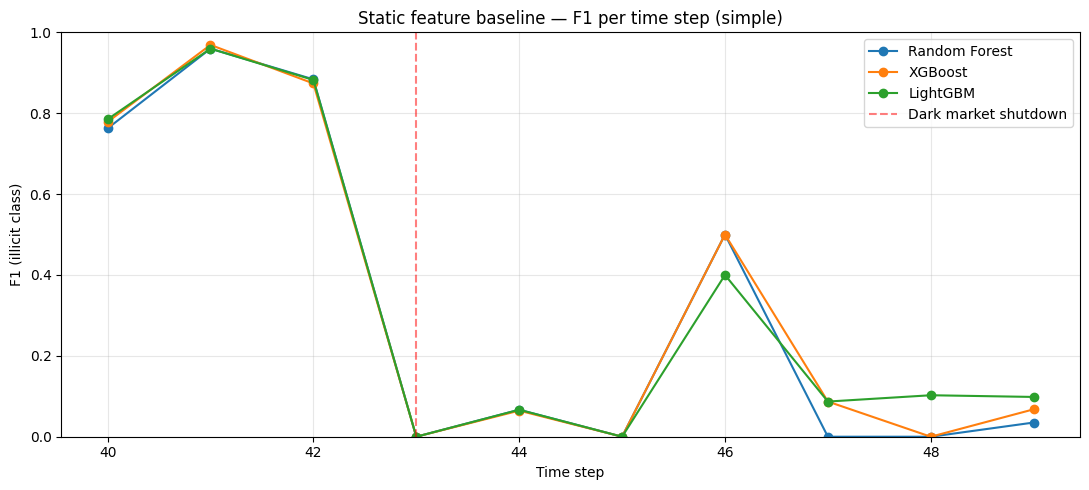

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))

for label, df in [
    ("Random Forest", rf_per_ts["simple"]),
    ("XGBoost",       xgb_per_ts["simple"]),
    ("LightGBM",      lgbm_per_ts["simple"]),
]:
    ax.plot(df["time_step"], df["f1"], marker="o", label=label)

ax.axvline(43, color="red", linestyle="--", alpha=0.5, label="Dark market shutdown")
ax.set_xlabel("Time step")
ax.set_ylabel("F1 (illicit class)")
ax.set_title("Static feature baseline — F1 per time step (simple)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
# plt.savefig("results/rq2/baseline_f1_per_timestep.png", dpi=150)
plt.show()

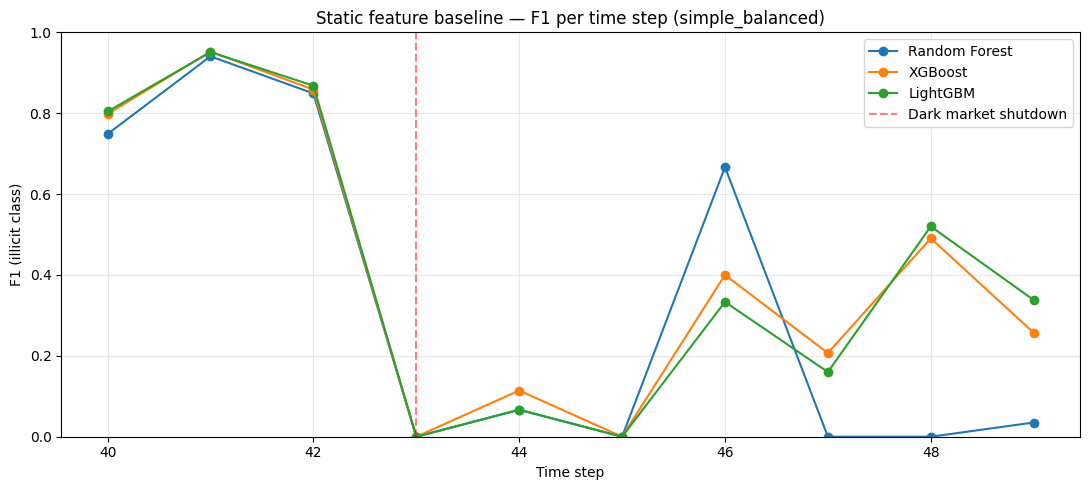

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))

for label, df in [
    ("Random Forest", rf_per_ts["simple_balanced"]),
    ("XGBoost",       xgb_per_ts["simple_balanced"]),
    ("LightGBM",      lgbm_per_ts["simple_balanced"]),
]:
    ax.plot(df["time_step"], df["f1"], marker="o", label=label)

ax.axvline(43, color="red", linestyle="--", alpha=0.5, label="Dark market shutdown")
ax.set_xlabel("Time step")
ax.set_ylabel("F1 (illicit class)")
ax.set_title("Static feature baseline — F1 per time step (simple_balanced)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
# plt.savefig("results/rq2/baseline_f1_per_timestep.png", dpi=150)
plt.show()

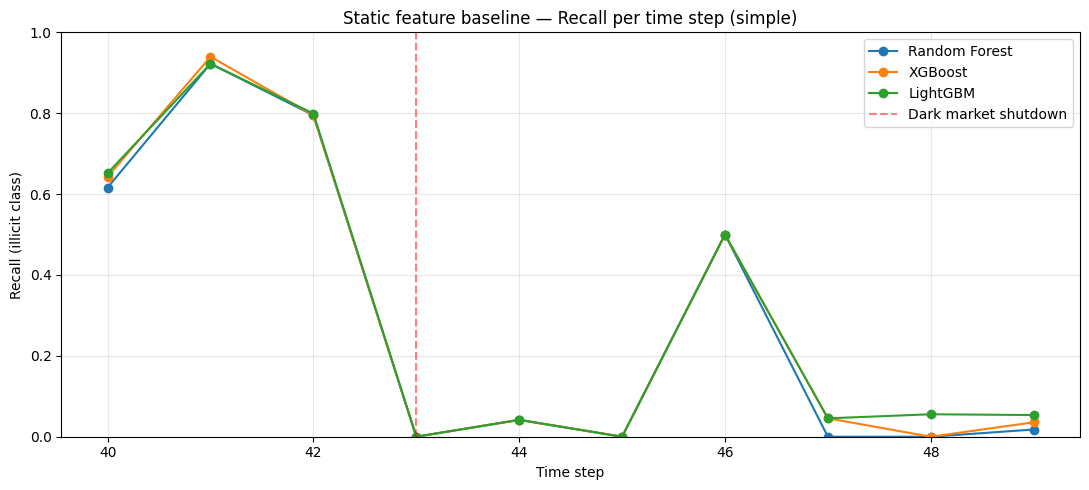

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))

for label, df in [
    ("Random Forest", rf_per_ts["simple"]),
    ("XGBoost",       xgb_per_ts["simple"]),
    ("LightGBM",      lgbm_per_ts["simple"]),
]:
    ax.plot(df["time_step"], df["recall"], marker="o", label=label)

ax.axvline(43, color="red", linestyle="--", alpha=0.5, label="Dark market shutdown")
ax.set_xlabel("Time step")
ax.set_ylabel("Recall (illicit class)")
ax.set_title("Static feature baseline — Recall per time step (simple)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
# plt.savefig("results/rq2/baseline_f1_per_timestep.png", dpi=150)
plt.show()

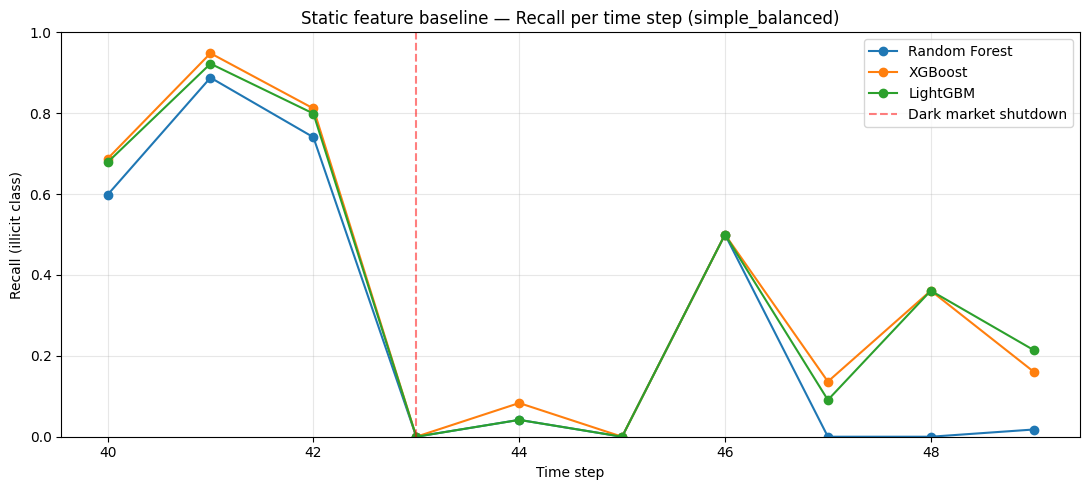

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))

for label, df in [
    ("Random Forest", rf_per_ts["simple_balanced"]),
    ("XGBoost",       xgb_per_ts["simple_balanced"]),
    ("LightGBM",      lgbm_per_ts["simple_balanced"]),
]:
    ax.plot(df["time_step"], df["recall"], marker="o", label=label)

ax.axvline(43, color="red", linestyle="--", alpha=0.5, label="Dark market shutdown")
ax.set_xlabel("Time step")
ax.set_ylabel("Recall (illicit class)")
ax.set_title("Static feature baseline — Recall per time step (simple_balanced)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
# plt.savefig("results/rq2/baseline_f1_per_timestep.png", dpi=150)
plt.show()

#### **Results:**
---
From the **aggregated results**, ***LightGBM with the simple_balanced setup is the best static baseline model***. It achieves the highest F1 score (0.755), while also keeping a strong ROC-AUC (~0.95). Compared to XGBoost and Random Forest, it provides the best balance between precision and recall. In general, we see a clear pattern: class balancing improves the performance of gradient boosting models (XGBoost and LightGBM), but not Random Forest. Random Forest keeps very high precision but lower recall, while the balanced boosting models increase recall and overall F1, which is more important for detecting illicit transactions.

Looking at the **F1 score plots**, all three models perform very well in the early time steps (40–42), where the data is similar to training. However, at time step 43, all models completely fail (F1 = 0), showing a strong concept drift caused by the dark market shutdown. After this point, Random Forest almost fully collapses and stays near zero. In contrast, XGBoost and LightGBM recover partially. LightGBM often performs the best in later time steps, especially around steps 48 and 49, where it achieves higher F1 scores than the other models. This shows that gradient boosting models are more robust to changes in the data.

The **recall plots show a similar pattern**. Before the drift, all models have high recall, meaning they detect most illicit transactions. After the drift, recall drops sharply for all models at step 43. Random Forest remains very low, missing almost all illicit transactions. However, XGBoost and LightGBM recover some recall in later steps. LightGBM again performs slightly better overall, detecting more illicit transactions than the other models while still keeping good precision.

Overall, these results confirm that LightGBM (simple_balanced) is the strongest static feature baseline. It performs best on average and is more robust after the concept drift, although all static models still struggle when the data distribution changes.

---
---

## **Static GNN:**
---

In [ ]:
from src.data_loader import _load_transactions_edgelist

print(_load_transactions_edgelist().head())
print(_load_transactions_edgelist().shape)

In [ ]:
from src.data_loader import load_transactions_graph_gcn

simple_gcn = load_transactions_graph_gcn()
simple_gcn

In [ ]:
from src.training import run_gcn_experiments

gcn_agg, gcn_per_ts = run_gcn_experiments()
print("Simple 2 Layer GCN - Agg")
display(gcn_agg)

In [ ]:
print("Simple 2 Layer GCN — simple")
display(gcn_per_ts[gcn_per_ts["setup"] == "simple"])

print("Simple 2 Layer GCN — simple_balanced")
display(gcn_per_ts[gcn_per_ts["setup"] == "simple_balanced"])

In [ ]:
from src.training import run_graphsage_experiments

sage_agg, sage_per_ts = run_graphsage_experiments()
print("2 Layer graphSAGE - Agg")
display(sage_agg)

In [ ]:
print("2 Layer graphSAGE - simple")
display(sage_per_ts[sage_per_ts["setup"] == "simple"])

print("2 Layer graphSAGE - simple_balanced")
display(sage_per_ts[sage_per_ts["setup"] == "simple_balanced"])

## **DynamicGNN**:
---

In [ ]:
from src.training import run_evolve_gcn_experiments

evolve_summary, evolve_per_ts = run_evolve_gcn_experiments()

print("EvolveGCN-O - Agg")
display(evolve_summary)

print("EvolveGCN-O - simple")
display(evolve_per_ts["simple"])

print("EvolveGCN-O - simple_balanced")
display(evolve_per_ts["simple_balanced"])

Due to the high computational demands of the EvolveGCN-O experiments, the model was trained on Google Colab using GPU acceleration. Specifically, the experiments were executed with 50 training epochs and a fixed random seed of 42 on an NVIDIA RTX PRO 6000 Blackwell Server Edition GPU. The generated outputs and evaluation results were subsequently stored in the `models` directory for further analysis and reproducibility.

In [4]:
import pandas as pd

simple_df = pd.read_csv(project_root / "models" / "evolve_simple.csv")
balanced_df = pd.read_csv(project_root / "models" / "evolve_simple_balanced.csv")
summary_df = pd.read_csv(project_root / "models" / "evolve_summary.csv")

In [5]:
print("=== EvolveGCN-O - Agg ===")
display(summary_df)

=== EvolveGCN-O - Agg ===


,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-graph,EvolveGCN-O,simple,0.176630,0.064936,0.995283,0.121918,0.538950
1,elliptic-transactions-graph,EvolveGCN-O,simple_balanced,0.183403,0.063635,0.963836,0.119388,0.532075


In [6]:
print("=== EvolveGCN-O - simple ===")
display(simple_df)

=== EvolveGCN-O - simple ===


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,0.095034,0.991071,0.173437,0.477846
1,41,1127,116,0.123922,0.991379,0.220307,0.345105
2,42,2142,239,0.120020,0.995816,0.214221,0.567425
3,43,1327,24,0.019640,1.000000,0.038523,0.510776
4,44,1578,24,0.022099,1.000000,0.043243,0.704486
5,45,1198,5,0.004500,1.000000,0.008961,0.532942
6,46,711,2,0.002990,1.000000,0.005961,0.823695
7,47,836,22,0.028097,1.000000,0.054658,0.639630
8,48,471,36,0.080537,1.000000,0.149068,0.728608
9,49,476,56,0.159544,1.000000,0.275184,0.766879


In [7]:
print("=== EvolveGCN-O - simple_balanced ===")
display(balanced_df)

=== EvolveGCN-O - simple_balanced ===


,time_step,n_samples,n_positives,precision,recall,f1,roc_auc
0,40,1208,112,0.094209,0.973214,0.171789,0.408327
1,41,1127,116,0.107692,0.844828,0.191033,0.318326
2,42,2142,239,0.120611,0.991632,0.215064,0.572742
3,43,1327,24,0.019737,1.000000,0.038710,0.537062
4,44,1578,24,0.022059,1.000000,0.043165,0.699901
5,45,1198,5,0.004570,1.000000,0.009099,0.448030
6,46,711,2,0.003012,1.000000,0.006006,0.800071
7,47,836,22,0.028314,1.000000,0.055069,0.596521
8,48,471,36,0.088889,1.000000,0.163265,0.734866
9,49,476,56,0.156863,1.000000,0.271186,0.815412
